# LazuliTarget

LazuliTarget (and co) are top level `class` with convenient methods and attributes for simple interaction with expected lazuli observations.

You can setup the instrument to reach the desired spectrum quality (`setup_to_snr()`), access expected spectrum (`get_spectrum`), change target's or instrument's properties etc. 

For convenience, 3 `LazuliTarget`s have been implemented
- `LazuliTarget`: the most generic, provide any spectrum you want
- `LazuliSN`: the Supernova specific, provide SN properties directly and rest will follow
- `LazuliCalSpec`: the standard star object to quickly obtain Standard star spectro.

*All have the same methods.*

**Note** 

LazuliTarget is what you get together with the exposure time when calling slicersim.lazuli_etc():
```python
exptime, lazusitarget = slicersim.lazuli_etc()
```

In [20]:
import slicersim

***
## Any Target

In [21]:
import numpy as np

In [22]:
# fake flat spectrum
lbda = np.arange(3_000, 20_000, 0.5) # every 0.5A
flux = np.ones( lbda.shape )

### Create a LazuliTarget

you can change the desired magnitude (e.g. 20 mag in "lsstg") while initiating the object

In [23]:
target = slicersim.LazuliTarget(lbda, flux, mag=20, band="lsstg")

### Setup the instrument

to reach the desired signal to noise ratio. Say here an average of 15 between 5000 A and 8000 A.

*this should take a few seconds, time to fit for the best configuration*

In [24]:
# in addition to set taget's detector to the correct configuration. 
# setup_to_snr returns this configuration and the reached snr
read_config, snr = target.setup_to_snr(15, lbda_range=[5000, 8000])

### Get the spectrum

You can now access the spectrum as it would be observed by Lazuli.

You can request is in adu or flambda (see doc). You can apply or not the noise to it

In [25]:
lbda, flux, variance = target.get_spectrum(unit="adu")
lbda, flux_nonoise, variance_nonoise = target.get_spectrum(unit="adu", incl_error=False)

The variance is the same but not the flux

In [26]:
(variance==variance_nonoise).all()

True

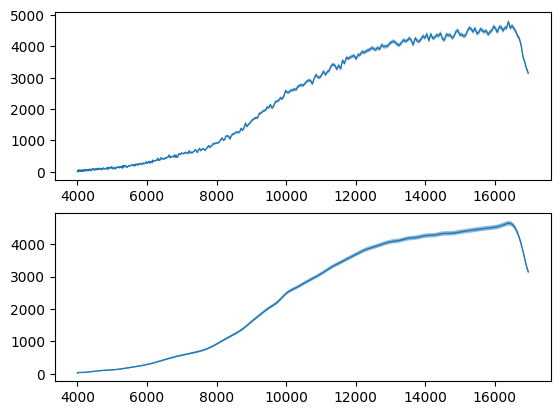

In [27]:
import matplotlib.pyplot as plt
fig, (ax, ax_nonoise) = plt.subplots(nrows=2)

# noise already applied to flux (realistic)
ax.plot(lbda, flux, lw=1)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.5)

# noise not applied to flux ('truth')
ax_nonoise.plot(lbda, flux_nonoise, lw=1)
ax_nonoise.fill_between(lbda, 
                flux_nonoise+np.sqrt(variance), 
                flux_nonoise-np.sqrt(variance), alpha=0.5)


***
## CalSpec standard star

Reference stars, and notably flux-calibrated CalSpec stars also are usual targets to be observe to calibrate the survey. 

We hence develop a LazuliTarget wrapper for calspec target. It loads a LazuliTarget-like directly from the calspec name.

For instance, let's load the spectrum for BD-17.

In [28]:
lazuli_bd17 = slicersim.LazuliCalSpec("bd_17")

In [29]:
# Say I want an average signal to noise of 40 between 4000A and 8000A
_ = lazuli_bd17.setup_to_snr(40, lbda_range=[4_000, 8_000])

You can specify "flambda" in `get_spectrum()` to get it in physical units

In [30]:
lbda, flux, variance = lazuli_bd17.get_spectrum(unit="flambda")

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1131: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramp"))


/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_67855/1030694407.py:7: RuntimeWarning: invalid value encountered in subtract
  flux-np.sqrt(variance), alpha=0.5)


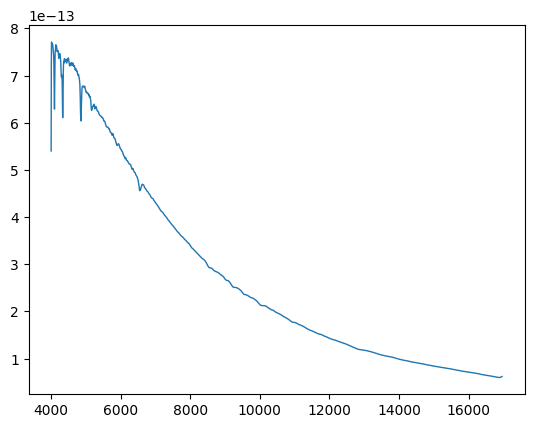

In [31]:
fig, ax = plt.subplots()

# noise already applied to flux (realistic)
ax.plot(lbda, flux, lw=1)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.5)


here is a list of all available sources

In [32]:
lazuli_bd17.source_names

array(['109vir', '109vir', '10lac', '10lac', '16cygb', '16cygb',
       '1732526', '1732526', '1740346', '1743045', '1743045', '1757132',
       '1757132', '1802271', '1802271', '1805292', '1805292', '1808347',
       '1808347', '1812095', '1812095', '1812524', '18sco', '18sco',
       '2m003618', '2m055914', '', 'agk_81d266', 'alpha_lyr', 'alpha_lyr',
       'bd02d3375', 'bd02d3375', 'bd11d3759', 'bd21d0607', 'bd21d0607',
       'bd26d2606', 'bd26d2606', 'bd29d2091', 'bd29d2091', 'bd54d1216',
       'bd54d1216', 'bd60d1753', 'bd60d1753', 'bd_17d4708', 'bd_28d4211',
       'bd_75d325', 'c26202', 'c26202', 'delumi', 'delumi', 'eta1dor',
       'eta1dor', 'etauma', 'etauma', 'feige110', 'feige34', 'g191b2b',
       'g191b2b', 'g191b2b', 'gd153', 'gd153', 'gd71', 'gd71', 'gj7541a',
       'gj7541a', 'grw_70d5824', 'grw_70d5824', 'hd009051', 'hd009051',
       'hd031128', 'hd031128', 'hd074000', 'hd074000', 'hd101452',
       'hd101452', 'hd106252', 'hd106252', 'hd111980', 'hd111980',
    

***
## Supernovae

Supernovae are at the core target of the Lazuli spectropgraph mission. We hence developed a LazuliTarget-like object dedicated to handle this kind of data

In [33]:
lazuli_snia = slicersim.LazuliSN(redshift=0.9, x1=1.2, c=0.2)

In [34]:
# Say I want an average signal to noise of 20 between 4000A and 8000A rest-frame
_ = lazuli_snia.setup_to_snr(20, lbda_range=[6000, 7000], frame="rest")

In [35]:
# get the flux model (incl_error=False) with the correct expected variance
lbda, flux, variance = lazuli_snia.get_spectrum(unit="flambda", incl_error=False)

/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_67855/1030694407.py:7: RuntimeWarning: invalid value encountered in subtract
  flux-np.sqrt(variance), alpha=0.5)


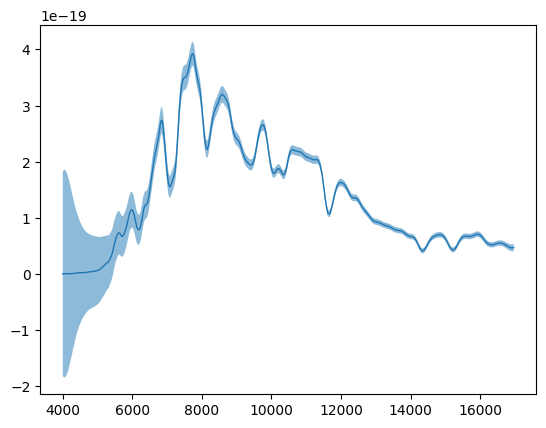

In [36]:
fig, ax = plt.subplots()

# noise already applied to flux (realistic)
ax.plot(lbda, flux, lw=1)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.5)


***
## Get exposure time

You can access the exposure at anytime associated to the current configuration using

In [37]:
lazuli_snia.get_exposure_time() # in second

5795.84

You can also obtain details associated to this time (read-frame time, ramp time etc.)

In [38]:
lazuli_snia.get_exposure_time(full=True) # in second

{'integration_time': 1426.32,
 'exposure_time': 1448.96,
 'tframe': 2.83,
 'tgroup': 22.64,
 'total_exptime': 5795.84}

***
## Detector read mode

The detector read-out mode (configuration) is also returned when you run `setup_to_snr()`. 
You can also access it at anytime.

In [26]:
lazuli_snia.get_readout_config()

{'nmd': (64, 8, 0), 'nramp': 4}

by default 64 group is the maximum number of group allowed for a single ramp. You can change that using `change_detector_mode()` ; see dedicated notebook